# Modelos lineales de clasificación multiclase

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original", sep=r'\s+', header=None,
                 names=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name'])
df.set_index('car_name', inplace=True)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
car_name,,,,,,,,
chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0
ford torino,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0


Vamos a ver si en las variables predictoras hay diferencias significativas entre países de origen.

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('origin', axis=1)
y = df['origin']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (284, 7)
Tamaño del conjunto de prueba es: (122, 7)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
from scipy.stats import loguniform

num_vars = X_train.select_dtypes(include=['number']).columns.drop(['model_year', 'cylinders'])
num_processor = Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')),
                                ('scaler', StandardScaler())
                            ])
cyl_processor = OrdinalEncoder(categories=[['3', '4', '5', '6', '8']])
year_processor = OrdinalEncoder(categories=[['70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82']])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_processor, num_vars),
        ('cyl', cyl_processor, ['cylinders']),
        ('year', year_processor, ['model_year']),
        ])

model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('clf', LogisticRegression(solver='liblinear', max_iter=10000))
                        ])

grid = {'clf__penalty':['l1', 'l2'], 'clf__C':loguniform(1e-4, 1e4)}

grid_search = RandomizedSearchCV(estimator=model, param_distributions=grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)
test_score = f1_score(y_test, grid_search.best_estimator_.predict(X_test), average='weighted')
print(f'El mejor score de este modelo con los datos de entrenamiento es: {grid_search.best_score_:.3f} se obtiene con los siguientes hiperparámetos: {grid_search.best_params_}')
print(f'El score de este modelo con los datos de prueba es: {test_score:.3f}')

El mejor score de este modelo con los datos de entrenamiento es: 0.775 se obtiene con los siguientes hiperparámetos: {'clf__C': 223.53843370205067, 'clf__penalty': 'l1'}
El score de este modelo con los datos de prueba es: 0.721


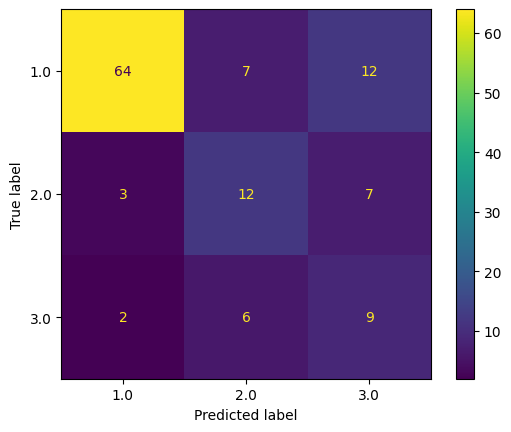

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test);

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, grid_search.predict(X_test)))

              precision    recall  f1-score   support

         1.0       0.93      0.77      0.84        83
         2.0       0.48      0.55      0.51        22
         3.0       0.32      0.53      0.40        17

    accuracy                           0.70       122
   macro avg       0.58      0.62      0.58       122
weighted avg       0.76      0.70      0.72       122



In [7]:
pesos = pd.DataFrame(data=grid_search.best_estimator_.named_steps['clf'].coef_, 
                     columns=grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out(), 
                     index=['pesos_1', 'pesos_2', 'pesos_3'])
pesos['intercept'] = grid_search.best_estimator_.named_steps['clf'].intercept_
pesos.T.round(3)

,pesos_1,pesos_2,pesos_3
num__mpg,-0.355,0.415,-0.107
num__displacement,20.581,-9.964,-6.068
num__horsepower,0.756,-1.905,2.183
num__weight,-7.497,6.057,-1.549
num__acceleration,0.636,-0.390,0.027
cyl__cylinders,-3.030,0.710,1.197
year__model_year,0.222,-0.258,0.156
intercept,11.534,-4.772,-7.692


Puede intentarse aplicar balanceo de clases también.

In [8]:
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('clf', LogisticRegression(solver='liblinear', max_iter=10000, class_weight='balanced'))
                        ])

grid = {'clf__penalty':['l1', 'l2'], 'clf__C':loguniform(1e-4, 1e4)}

grid_search = RandomizedSearchCV(estimator=model, param_distributions=grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)
test_score = f1_score(y_test, grid_search.best_estimator_.predict(X_test), average='weighted')
print(f'El mejor score de este modelo con los datos de entrenamiento es: {grid_search.best_score_:.3f} se obtiene con los siguientes hiperparámetos: {grid_search.best_params_}')
print(f'El score de este modelo con los datos de prueba es: {test_score:.3f}')

El mejor score de este modelo con los datos de entrenamiento es: 0.802 se obtiene con los siguientes hiperparámetos: {'clf__C': 6004.356401338358, 'clf__penalty': 'l1'}
El score de este modelo con los datos de prueba es: 0.728


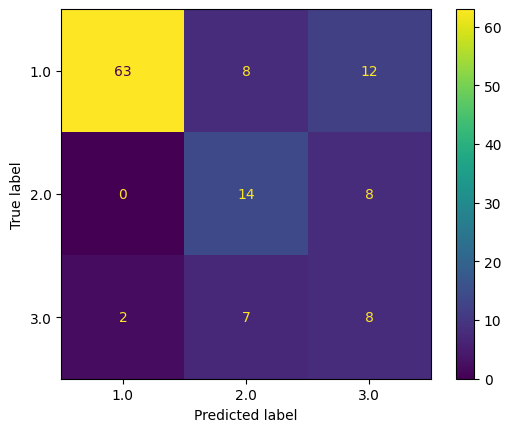

In [9]:
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test);

In [10]:
print(classification_report(y_test, grid_search.predict(X_test)))

              precision    recall  f1-score   support

         1.0       0.97      0.76      0.85        83
         2.0       0.48      0.64      0.55        22
         3.0       0.29      0.47      0.36        17

    accuracy                           0.70       122
   macro avg       0.58      0.62      0.59       122
weighted avg       0.79      0.70      0.73       122

